In [ ]:
!pip install torchaudio git+https://github.com/lucadellalib/focalcodec.git transformers librosa soundfile

  Cloning https://github.com/lucadellalib/focalcodec.git to /tmp/pip-req-build-gerbw0dp
  Running command git clone --filter=blob:none --quiet https://github.com/lucadellalib/focalcodec.git /tmp/pip-req-build-gerbw0dp
  Resolved https://github.com/lucadellalib/focalcodec.git to commit 912b7f2c0cd43d54a8aed296bbcc925dec7d4ea3
  Preparing metadata (setup.py) ... done
  Created wheel for focalcodec: filename=focalcodec-0.0.2-py3-none-any.whl size=49223 sha256=562d9d972971783d097b4f81282e4e3723daf1336fa60b86dedb62c5b6acc670
  Stored in directory: /tmp/pip-ephem-wheel-cache-co8_hy4o/wheels/8d/c6/c8/cec30556078947c251df506edcc38928b5bb208bdd569bc805
Successfully built focalcodec


0 tokens, 0.50s
  text: The quick brown fox jumps over the lazy dog.


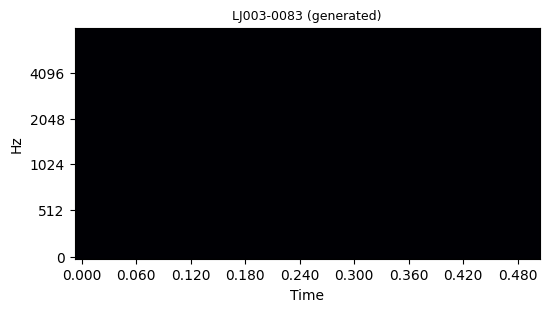

In [ ]:
# inference
text = "The quick brown fox jumps over the lazy dog."

def sample_tts(text, max_new=400, temperature=0.9, top_k=100):
    text_ids = torch.tensor(tokenizer.encode(text, add_special_tokens=False), device=device)
    toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k)
    if toks.numel() == 0: return np.zeros(CODEC_SR // 2, dtype=np.float32), toks
    with torch.no_grad():
        wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0).detach().cpu().numpy().astype(np.float32)
    return wav, toks

wav, toks = sample_tts(text)
print(f'{toks.numel()} tokens, {wav.shape[-1]/CODEC_SR:.2f}s')
print(f'  text: {text}')
plot_mel(wav, CODEC_SR, f'{row["id"]} (generated)')
display.display(display.Audio(wav, rate=CODEC_SR))

---------------------------


In [1]:
!pip -q install openai-whisper jiwer speechbrain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 14.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 20.9 MB/s eta 0:00:00


In [ ]:

!pip -q install torchaudio git+https://github.com/lucadellalib/focalcodec.git transformers pytorch-lightning librosa soundfile

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from dataclasses import dataclass
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from focalcodec import FocalCodec

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


codec = FocalCodec.from_pretrained("lucadellalib/focalcodec_25hz").to(device).eval()

for p in codec.parameters():
    p.requires_grad_(False)

CODEBOOK_SIZE = int(codec.codebook.shape[0])
CODEC_SR = codec.sample_rate_input
GEN_SR = codec.sample_rate_output

print("CODEBOOK_SIZE:", CODEBOOK_SIZE)
print("codec sample rates:", CODEC_SR, GEN_SR)


tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")


@dataclass
class GPT2TTSConfig:
    base_model: str = "gpt2"
    codebook_size: int = CODEBOOK_SIZE
    n_special_tokens: int = 2

    @property
    def audio_vocab_size(self):
        return self.codebook_size + self.n_special_tokens

    @property
    def bos_id(self):
        return self.codebook_size

    @property
    def eos_id(self):
        return self.codebook_size + 1


class GPT2TTS(nn.Module):
    def __init__(self, cfg: GPT2TTSConfig):
        super().__init__()
        self.cfg = cfg

        self.base = GPT2LMHeadModel.from_pretrained(cfg.base_model)

        H = self.base.config.n_embd
        V = cfg.audio_vocab_size

        self.audio_emb = nn.Embedding(V, H)
        self.audio_head = nn.Linear(H, V, bias=False)

        nn.init.normal_(self.audio_emb.weight, std=0.02)
        nn.init.normal_(self.audio_head.weight, std=0.02)

    def _build_inputs(self, text_ids, text_lens, audio_ids, audio_lens):
        B = text_ids.shape[0]
        H = self.base.config.n_embd

        L = int((text_lens + audio_lens).max().item()) + 2

        text_emb = self.base.transformer.wte(text_ids)
        audio_emb = self.audio_emb(audio_ids)

        bos_emb = self.audio_emb.weight[self.cfg.bos_id]
        eos_emb = self.audio_emb.weight[self.cfg.eos_id]

        inputs = torch.zeros(B, L, H, device=text_ids.device, dtype=text_emb.dtype)
        mask = torch.zeros(B, L, device=text_ids.device, dtype=torch.long)
        labels = torch.full((B, L), -100, device=text_ids.device, dtype=torch.long)

        for i in range(B):
            tl = int(text_lens[i].item())
            al = int(audio_lens[i].item())

            inputs[i, :tl] = text_emb[i, :tl]
            inputs[i, tl] = bos_emb
            inputs[i, tl + 1 : tl + 1 + al] = audio_emb[i, :al]
            inputs[i, tl + 1 + al] = eos_emb

            mask[i, : tl + al + 2] = 1

            labels[i, tl + 1 : tl + 1 + al] = audio_ids[i, :al]
            labels[i, tl + 1 + al] = self.cfg.eos_id

        return inputs, mask, labels

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        inputs, mask, labels = self._build_inputs(
            text_ids=text_ids,
            text_lens=text_lens,
            audio_ids=audio_ids,
            audio_lens=audio_lens,
        )

        h = self.base.transformer(
            inputs_embeds=inputs,
            attention_mask=mask,
            return_dict=True,
        ).last_hidden_state

        logits = self.audio_head(h)

        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)).float(),
            shift_labels.view(-1),
            ignore_index=-100,
        )

        return {"loss": loss, "logits": logits}

    @torch.no_grad()
    def generate_audio(
        self,
        text_ids,
        max_new_tokens=400,
        temperature=0.9,
        top_k=0,
        top_p=1.0,
    ):
        self.eval()

        device = text_ids.device
        text_ids = text_ids.view(-1).long().to(device)

        text_emb = self.base.transformer.wte(text_ids).unsqueeze(0)
        bos_emb = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)

        prefix = torch.cat([text_emb, bos_emb], dim=1)
        attention_mask = torch.ones(
            1,
            prefix.size(1),
            device=device,
            dtype=torch.long,
        )

        out = self.base.transformer(
            inputs_embeds=prefix,
            attention_mask=attention_mask,
            use_cache=True,
            return_dict=True,
        )

        past = out.past_key_values
        h = out.last_hidden_state[:, -1, :]

        generated = []

        for _ in range(max_new_tokens):
            logits = self.audio_head(h).squeeze(0).squeeze(0)

            # Do not generate BOS again
            logits[self.cfg.bos_id] = -float("inf")

            # Greedy decoding
            if temperature == 0:
                next_token = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits = logits / temperature

                # Top-k filtering
                if top_k is not None and top_k > 0:
                    k = min(top_k, logits.size(-1))
                    values, _ = torch.topk(logits, k)
                    threshold = values[-1]
                    logits = torch.where(
                        logits < threshold,
                        torch.full_like(logits, -float("inf")),
                        logits,
                    )

                # Top-p / nucleus filtering
                if top_p is not None and top_p < 1.0:
                    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                    sorted_probs = F.softmax(sorted_logits, dim=-1)
                    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                    remove_mask = cumulative_probs > top_p
                    remove_mask[1:] = remove_mask[:-1].clone()
                    remove_mask[0] = False

                    sorted_logits[remove_mask] = -float("inf")

                    filtered_logits = torch.full_like(logits, -float("inf"))
                    filtered_logits.scatter_(0, sorted_indices, sorted_logits)
                    logits = filtered_logits

                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)

            token_id = int(next_token.item())

            if token_id == self.cfg.eos_id:
                break

            if token_id < self.cfg.codebook_size:
                generated.append(token_id)

            next_emb = self.audio_emb(next_token.view(1, 1))

            attention_mask = torch.cat(
                [
                    attention_mask,
                    torch.ones(1, 1, device=device, dtype=torch.long),
                ],
                dim=1,
            )

            out = self.base.transformer(
                inputs_embeds=next_emb,
                attention_mask=attention_mask,
                past_key_values=past,
                use_cache=True,
                return_dict=True,
            )

            past = out.past_key_values
            h = out.last_hidden_state[:, -1, :]

        return torch.tensor(generated, dtype=torch.long, device=device)


class TTSLightningModule(pl.LightningModule):
    def __init__(self, cfg, tts_model=None):
        super().__init__()
        self.save_hyperparameters(ignore=["tts_model"])
        self.cfg = cfg
        self.model = tts_model if tts_model is not None else GPT2TTS(cfg)

    def forward(self, **kwargs):
        return self.model(**kwargs)

    def training_step(self, batch, batch_idx):
        output = self(**batch)
        loss = output["loss"]
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        output = self(**batch)
        loss = output["loss"]
        self.log("val_loss", loss, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=3e-4,
            weight_decay=0.01,
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=20,
        )

        return {"optimizer": optimizer, "lr_scheduler": scheduler}


print("Recovery definitions loaded.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.3 MB/s eta 0:00:00
device: cuda


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/577M [00:00<?, ?B/s]

CODEBOOK_SIZE: 8192
codec sample rates: 16000 16000


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Recovery definitions loaded.


In [ ]:
import os
import torch

CKPT_PATH = "/content/drive/MyDrive/last.ckpt"

assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading trusted checkpoint:", CKPT_PATH)

ckpt = torch.load(
    CKPT_PATH,
    map_location=device,
    weights_only=False,
)

print("Checkpoint keys:", ckpt.keys())

state_dict = ckpt["state_dict"]

print("First checkpoint keys:")
for k in list(state_dict.keys())[:10]:
    print(k)

cfg = GPT2TTSConfig(codebook_size=CODEBOOK_SIZE)

tts = GPT2TTS(cfg).to(device)

# Lightning saves model weights with prefix "model."
clean_state_dict = {}

for k, v in state_dict.items():
    if k.startswith("model."):
        new_k = k[len("model."):]
    else:
        new_k = k

    clean_state_dict[new_k] = v

missing, unexpected = tts.load_state_dict(clean_state_dict, strict=False)

tts.eval()

print("Checkpoint loaded into GPT2TTS.")
print("Missing keys:", missing[:20])
print("Unexpected keys:", unexpected[:20])

Loading trusted checkpoint: /content/drive/MyDrive/last.ckpt
Checkpoint keys: dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'MixedPrecision', 'hparams_name', 'hyper_parameters'])
First checkpoint keys:
model.base.transformer.wte.weight
model.base.transformer.wpe.weight
model.base.transformer.h.0.ln_1.weight
model.base.transformer.h.0.ln_1.bias
model.base.transformer.h.0.attn.c_attn.weight
model.base.transformer.h.0.attn.c_attn.bias
model.base.transformer.h.0.attn.c_proj.weight
model.base.transformer.h.0.attn.c_proj.bias
model.base.transformer.h.0.ln_2.weight
model.base.transformer.h.0.ln_2.bias


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint loaded into GPT2TTS.
Missing keys: []
Unexpected keys: []


In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_audio_patched(
    self,
    text_ids,
    max_new_tokens=400,
    temperature=0.9,
    top_k=0,
    top_p=1.0,
):
    self.eval()

    device = text_ids.device
    text_ids = text_ids.view(-1).long().to(device)

    text_emb = self.base.transformer.wte(text_ids).unsqueeze(0)
    bos = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)

    prefix = torch.cat([text_emb, bos], dim=1)
    mask = torch.ones(1, prefix.size(1), device=device, dtype=torch.long)

    out = self.base.transformer(
        inputs_embeds=prefix,
        attention_mask=mask,
        use_cache=True,
        return_dict=True,
    )

    past = out.past_key_values
    h = out.last_hidden_state[:, -1, :]

    generated = []

    for _ in range(max_new_tokens):
        logits = self.audio_head(h).squeeze(0).squeeze(0)

    
        logits[self.cfg.bos_id] = -float("inf")

    
        if temperature == 0:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / temperature

            # Top-k filtering
            if top_k is not None and top_k > 0:
                k = min(top_k, logits.size(-1))
                values, _ = torch.topk(logits, k)
                threshold = values[-1]
                logits = torch.where(
                    logits < threshold,
                    torch.full_like(logits, -float("inf")),
                    logits,
                )

            # Top-p / nucleus filtering
            if top_p is not None and top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                remove_mask = cumulative_probs > top_p
                remove_mask[1:] = remove_mask[:-1].clone()
                remove_mask[0] = False

                sorted_logits[remove_mask] = -float("inf")

                filtered_logits = torch.full_like(logits, -float("inf"))
                filtered_logits.scatter_(0, sorted_indices, sorted_logits)
                logits = filtered_logits

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        token_id = int(next_token.item())

        if token_id == self.cfg.eos_id:
            break

        if token_id < self.cfg.codebook_size:
            generated.append(token_id)

        next_emb = self.audio_emb(next_token.view(1, 1))

        mask = torch.cat(
            [mask, torch.ones(1, 1, device=device, dtype=torch.long)],
            dim=1,
        )

        out = self.base.transformer(
            inputs_embeds=next_emb,
            attention_mask=mask,
            past_key_values=past,
            use_cache=True,
            return_dict=True,
        )

        past = out.past_key_values
        h = out.last_hidden_state[:, -1, :]

    return torch.tensor(generated, dtype=torch.long, device=device)


tts.generate_audio = generate_audio_patched.__get__(tts, type(tts))

print("generate_audio patched successfully.")

generate_audio patched successfully.


In [10]:
import os
import numpy as np
import soundfile as sf
import IPython.display as display

GEN_SR = getattr(codec, "sample_rate_output", CODEC_SR)

OUT_DIR = "/content/drive/MyDrive/tts_eval_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

@torch.no_grad()
def sample_tts(
    text,
    max_new=400,
    temperature=0.9,
    top_k=0,
    top_p=1.0,
):
    text_ids = torch.tensor(
        tokenizer.encode(text, add_special_tokens=False),
        device=device,
        dtype=torch.long,
    )

    toks = tts.generate_audio(
        text_ids,
        max_new_tokens=max_new,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
    )

    if toks.numel() == 0:
        wav = np.zeros(GEN_SR // 2, dtype=np.float32)
        return wav, toks

    wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0)
    wav = wav.detach().cpu().numpy().astype(np.float32)

    return wav, toks

In [11]:
text = "The quick brown fox jumps over the lazy dog."

wav, toks = sample_tts(
    text,
    max_new=400,
    temperature=0.8,
    top_k=50,
    top_p=0.9,
)

print("Text:", text)
print("Generated tokens:", toks.numel())
print("Duration:", len(wav) / GEN_SR)

display.display(display.Audio(wav, rate=GEN_SR))


Text: The quick brown fox jumps over the lazy dog.
Generated tokens: 75
Duration: 3.0


In [27]:
SAMPLING_CONFIGS = [
    {
        "name": "greedy",
        "temperature": 0.0,
        "top_k": 0,
        "top_p": 1.0,
    },
    {
        "name": "top_k_50",
        "temperature": 0.8,
        "top_k": 50,
        "top_p": 1.0,
    },
    {
        "name": "top_p_090",
        "temperature": 0.8,
        "top_k": 0,
        "top_p": 0.90,
    },
    {
        "name": "top_k_50_top_p_090",
        "temperature": 0.8,
        "top_k": 50,
        "top_p": 0.90,
    },
]

test_texts = [
    "Hello, what is your name?",
    "London is the capital of Great Britan",
    "This is a short test sentence for speech synthesis.",
]

for text_id, text in enumerate(test_texts):
    print("=" * 100)
    print("TEXT:", text)

    for cfg_sampling in SAMPLING_CONFIGS:
        wav, toks = sample_tts(
            text,
            max_new=400,
            temperature=cfg_sampling["temperature"],
            top_k=cfg_sampling["top_k"],
            top_p=cfg_sampling["top_p"],
        )

        out_path = f"{OUT_DIR}/manual_{text_id}_{cfg_sampling['name']}.wav"
        sf.write(out_path, wav, GEN_SR)

        print()
        print("Strategy:", cfg_sampling["name"])
        print("Tokens:", toks.numel())
        print("Duration:", len(wav) / GEN_SR)
        print("Saved:", out_path)

        display.display(display.Audio(wav, rate=GEN_SR))

TEXT: Hello, what is your name?

Strategy: greedy
Tokens: 52
Duration: 2.08
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_0_greedy.wav



Strategy: top_k_50
Tokens: 48
Duration: 1.92
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_0_top_k_50.wav



Strategy: top_p_090
Tokens: 57
Duration: 2.28
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_0_top_p_090.wav



Strategy: top_k_50_top_p_090
Tokens: 14
Duration: 0.56
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_0_top_k_50_top_p_090.wav


TEXT: London is the capital of Great Britan

Strategy: greedy
Tokens: 37
Duration: 1.48
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_1_greedy.wav


...


Strategy: top_k_50_top_p_090
Tokens: 75
Duration: 3.0
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_1_top_k_50_top_p_090.wav


TEXT: This is a short test sentence for speech synthesis.

Strategy: greedy
Tokens: 85
Duration: 3.4
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_2_greedy.wav



Strategy: top_k_50
Tokens: 84
Duration: 3.36
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_2_top_k_50.wav



Strategy: top_p_090
Tokens: 101
Duration: 4.04
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_2_top_p_090.wav



Strategy: top_k_50_top_p_090
Tokens: 84
Duration: 3.36
Saved: /content/drive/MyDrive/tts_eval_outputs/manual_2_top_k_50_top_p_090.wav


In [17]:
!pip -q install openai-whisper jiwer speechbrain

In [ ]:
import whisper
import jiwer
import torchaudio
import pandas as pd
from tqdm.auto import tqdm

whisper_model = whisper.load_model("base", device=device)

utmos_model = torch.hub.load(
    "tarepan/SpeechMOS:v1.2.0",
    "utmos22_strong",
    trust_repo=True,
)
utmos_model = utmos_model.to(device).eval()

try:
    from speechbrain.inference.classifiers import EncoderClassifier
except ImportError:
    from speechbrain.pretrained import EncoderClassifier

speaker_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="/content/pretrained_ecapa",
    run_opts={"device": device},
)

print("Metric models loaded.")

100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 73.4MiB/s]


Downloading: "https://github.com/tarepan/SpeechMOS/zipball/v1.2.0" to /root/.cache/torch/hub/v1.2.0.zip


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Downloading: "https://github.com/tarepan/SpeechMOS/releases/download/v1.0.0/utmos22_strong_step7459_v1.pt" to /root/.cache/torch/hub/checkpoints/utmos22_strong_step7459_v1.pt


100%|██████████| 392M/392M [00:06<00:00, 63.4MB/s]
INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


...

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


label_encoder.txt: 0.00B [00:00, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


Metric models loaded.


In [19]:
def normalize_text_for_cer(text):
    text = str(text).lower().strip()
    text = jiwer.RemovePunctuation()(text)
    text = jiwer.RemoveMultipleSpaces()(text)
    text = jiwer.Strip()(text)
    return text


def compute_cer(reference_text, generated_wav_path):
    result = whisper_model.transcribe(
        generated_wav_path,
        language="en",
        fp16=(device == "cuda"),
    )

    hyp = normalize_text_for_cer(result["text"])
    ref = normalize_text_for_cer(reference_text)

    return jiwer.cer(ref, hyp), hyp


def compute_utmos(wav_path):
    wav, sr = torchaudio.load(wav_path)
    wav = wav.mean(dim=0, keepdim=True).to(device)

    with torch.no_grad():
        score = utmos_model(wav, sr)

    return float(score.squeeze().detach().cpu())


def load_wav_for_speaker(path):
    wav, sr = torchaudio.load(path)

    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)

    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)

    return wav.to(device)


def speaker_embedding(path):
    wav = load_wav_for_speaker(path)

    with torch.no_grad():
        emb = speaker_model.encode_batch(wav)

    return emb.squeeze()


def compute_secs(reference_wav_path, generated_wav_path):
    ref_emb = speaker_embedding(reference_wav_path)
    gen_emb = speaker_embedding(generated_wav_path)

    score = F.cosine_similarity(
        ref_emb.flatten(),
        gen_emb.flatten(),
        dim=0,
    )

    return float(score.detach().cpu())

In [21]:
import torchaudio
import os

root_dir = "./data"
os.makedirs(root_dir, exist_ok=True)

ljspeech_dataset = torchaudio.datasets.LJSPEECH(root=root_dir, download=True)

waveform, sample_rate, transcript, normalized_transcript = ljspeech_dataset[0]

print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)
print("Transcript:", transcript)

100%|██████████| 2.56G/2.56G [00:32<00:00, 83.9MB/s]


Waveform shape: torch.Size([1, 212893])
Sample rate: 22050
Transcript: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition


In [22]:
import pandas as pd
import numpy as np

meta = pd.read_csv(f'{root_dir}/LJSpeech-1.1/metadata.csv', sep='|', header=None,
                   names=['id', 'text', 'text_norm'])
meta['text_norm'] = meta['text_norm'].fillna(meta['text'])
meta['filepath'] = meta['id'].apply(lambda s: f'{root_dir}/LJSpeech-1.1/wavs/{s}.wav')

rng = np.random.default_rng(42)
perm = rng.permutation(len(meta))
split_at = int(0.9 * len(meta))
train_df = meta.iloc[perm[:split_at]].reset_index(drop=True)
val_df   = meta.iloc[perm[split_at:]].reset_index(drop=True)
print(f'train: {len(train_df)}  val: {len(val_df)}')
train_df.head(2)

train: 11790  val: 1310


,id,text,text_norm,filepath
0,LJ022-0092,and such projects as they approve will be next...,and such projects as they approve will be next...,./data/LJSpeech-1.1/wavs/LJ022-0092.wav
1,LJ039-0028,"was shipped from Los Angeles on March 20, 1963...","was shipped from Los Angeles on March twenty, ...",./data/LJSpeech-1.1/wavs/LJ039-0028.wav


In [23]:
N_EVAL = 5

assert "val_df" in globals(), "val_df is missing. Run the dataset split cell first."
assert "filepath" in val_df.columns, "val_df must contain filepath column."
assert "text_norm" in val_df.columns, "val_df must contain text_norm column."

eval_rows = val_df.sample(n=N_EVAL, random_state=42).reset_index(drop=True)

results = []

for i, row in tqdm(eval_rows.iterrows(), total=len(eval_rows)):
    reference_text = row["text_norm"]
    reference_wav_path = row["filepath"]

    for cfg_sampling in SAMPLING_CONFIGS:
        wav, toks = sample_tts(
            reference_text,
            max_new=400,
            temperature=cfg_sampling["temperature"],
            top_k=cfg_sampling["top_k"],
            top_p=cfg_sampling["top_p"],
        )

        generated_wav_path = f"{OUT_DIR}/eval_{i}_{cfg_sampling['name']}.wav"
        sf.write(generated_wav_path, wav, GEN_SR)

        cer_score, asr_text = compute_cer(reference_text, generated_wav_path)
        utmos_score = compute_utmos(generated_wav_path)
        secs_score = compute_secs(reference_wav_path, generated_wav_path)

        results.append(
            {
                "sample_id": row["id"],
                "strategy": cfg_sampling["name"],
                "reference_text": reference_text,
                "asr_text": asr_text,
                "n_tokens": int(toks.numel()),
                "duration_sec": len(wav) / GEN_SR,
                "CER": cer_score,
                "UTMOS": utmos_score,
                "SECS": secs_score,
                "generated_path": generated_wav_path,
                "reference_path": reference_wav_path,
            }
        )

results_df = pd.DataFrame(results)

csv_path = f"{OUT_DIR}/metrics_results.csv"
results_df.to_csv(csv_path, index=False)

print("Saved metrics to:", csv_path)

results_df

  0%|          | 0/5 [00:00<?, ?it/s]

Saved metrics to: /content/drive/MyDrive/tts_eval_outputs/metrics_results.csv


,sample_id,strategy,reference_text,asr_text,n_tokens,duration_sec,CER,UTMOS,SECS,generated_path,reference_path
0,LJ048-0043,greedy,nor was there any requirement to report the na...,we know air inna and formatition report in mis...,236,9.44,0.793893,3.944280,0.530905,/content/drive/MyDrive/tts_eval_outputs/eval_0...,./data/LJSpeech-1.1/wavs/LJ048-0043.wav
1,LJ048-0043,top_k_50,nor was there any requirement to report the na...,where i was the hematine erectione as steam of...,186,7.44,0.664122,4.152415,0.366205,/content/drive/MyDrive/tts_eval_outputs/eval_0...,./data/LJSpeech-1.1/wavs/LJ048-0043.wav
2,LJ048-0043,top_p_090,nor was there any requirement to report the na...,whether it were pierre in our duration appuite...,210,8.40,0.763359,4.250118,0.570583,/content/drive/MyDrive/tts_eval_outputs/eval_0...,./data/LJSpeech-1.1/wavs/LJ048-0043.wav
3,LJ048-0043,top_k_50_top_p_090,nor was there any requirement to report the na...,or he was not a rackety no cords of the receas...,243,9.72,0.717557,3.876025,0.536062,/content/drive/MyDrive/tts_eval_outputs/eval_0...,./data/LJSpeech-1.1/wavs/LJ048-0043.wav
4,LJ017-0020,greedy,would probably have had the benefit in these d...,were probable have then the stays of these asd...,153,6.12,0.530120,4.452579,0.520992,/content/drive/MyDrive/tts_eval_outputs/eval_1...,./data/LJSpeech-1.1/wavs/LJ017-0020.wav
5,LJ017-0020,top_k_50,would probably have had the benefit in these d...,rapubble would have hit these guns is tathese ...,137,5.48,0.626506,4.419814,0.567940,/content/drive/MyDrive/tts_eval_outputs/eval_1...,./data/LJSpeech-1.1/wavs/LJ017-0020.wav
6,LJ017-0020,top_p_090,would probably have had the benefit in these d...,where a brobble rames have a need of fish dend...,121,4.84,0.650602,4.456435,0.273282,/content/drive/MyDrive/tts_eval_outputs/eval_1...,./data/LJSpeech-1.1/wavs/LJ017-0020.wav
7,LJ017-0020,top_k_50_top_p_090,would probably have had the benefit in these d...,were probably quite heavily in the disease win...,113,4.52,0.554217,3.780294,0.293996,/content/drive/MyDrive/tts_eval_outputs/eval_1...,./data/LJSpeech-1.1/wavs/LJ017-0020.wav
8,LJ018-0085,greedy,He would shoot any man or any policeman like a...,he was an aniquelyness liplies a leasenot and ...,194,7.76,0.740385,3.934253,0.456505,/content/drive/MyDrive/tts_eval_outputs/eval_2...,./data/LJSpeech-1.1/wavs/LJ018-0085.wav
9,LJ018-0085,top_k_50,He would shoot any man or any policeman like a...,he shees shoole and on a hulane okinly come ar...,183,7.32,0.653846,4.211005,0.492449,/content/drive/MyDrive/tts_eval_outputs/eval_2...,./data/LJSpeech-1.1/wavs/LJ018-0085.wav


In [24]:
# Keep your trained model
tts_finetuned = tts

# Create the same architecture, but DO NOT load checkpoint
cfg_unfinetuned = GPT2TTSConfig(codebook_size=CODEBOOK_SIZE)

tts_unfinetuned = GPT2TTS(cfg_unfinetuned).to(device).eval()

# If you patched generate_audio as a separate function, attach it here too
if "generate_audio_patched" in globals():
    tts_unfinetuned.generate_audio = generate_audio_patched.__get__(
        tts_unfinetuned,
        type(tts_unfinetuned),
    )

print("Unfinetuned model created.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unfinetuned model created.


In [25]:
import numpy as np
import soundfile as sf
import IPython.display as display

GEN_SR = getattr(codec, "sample_rate_output", CODEC_SR)

@torch.no_grad()
def sample_tts_from_model(
    model,
    text,
    max_new=400,
    temperature=0.9,
    top_k=0,
    top_p=1.0,
):
    text_ids = torch.tensor(
        tokenizer.encode(text, add_special_tokens=False),
        device=device,
        dtype=torch.long,
    )

    toks = model.generate_audio(
        text_ids,
        max_new_tokens=max_new,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
    )

    if toks.numel() == 0:
        wav = np.zeros(GEN_SR // 2, dtype=np.float32)
        return wav, toks

    wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0)
    wav = wav.detach().cpu().numpy().astype(np.float32)

    return wav, toks

In [28]:
text = "This is a short test sentence for speech synthesis."

wav, toks = sample_tts_from_model(
    tts_unfinetuned,
    text,
    max_new=400,
    temperature=0.8,
    top_k=50,
    top_p=0.9,
)

print("Generated tokens:", toks.numel())
print("Duration:", len(wav) / GEN_SR)

display.display(display.Audio(wav, rate=GEN_SR))

Generated tokens: 400
Duration: 16.0


In [29]:
import os
import pandas as pd
from tqdm.auto import tqdm

OUT_DIR_UNFT = "/content/drive/MyDrive/tts_eval_outputs_unfinetuned"
os.makedirs(OUT_DIR_UNFT, exist_ok=True)

N_EVAL = 5

if "eval_rows" not in globals():
    assert "val_df" in globals(), "val_df is missing. Restore validation dataframe first."
    eval_rows = val_df.sample(n=N_EVAL, random_state=42).reset_index(drop=True)

unfinetuned_results = []

for i, row in tqdm(eval_rows.iterrows(), total=len(eval_rows)):
    reference_text = row["text_norm"]
    reference_wav_path = row["filepath"]

    for cfg_sampling in SAMPLING_CONFIGS:
        wav, toks = sample_tts_from_model(
            tts_unfinetuned,
            reference_text,
            max_new=400,
            temperature=cfg_sampling["temperature"],
            top_k=cfg_sampling["top_k"],
            top_p=cfg_sampling["top_p"],
        )

        generated_wav_path = (
            f"{OUT_DIR_UNFT}/eval_{i}_{cfg_sampling['name']}_unfinetuned.wav"
        )

        sf.write(generated_wav_path, wav, GEN_SR)

        cer_score, asr_text = compute_cer(reference_text, generated_wav_path)
        utmos_score = compute_utmos(generated_wav_path)
        secs_score = compute_secs(reference_wav_path, generated_wav_path)

        unfinetuned_results.append(
            {
                "model": "unfinetuned",
                "sample_id": row["id"],
                "strategy": cfg_sampling["name"],
                "reference_text": reference_text,
                "asr_text": asr_text,
                "n_tokens": int(toks.numel()),
                "duration_sec": len(wav) / GEN_SR,
                "CER": cer_score,
                "UTMOS": utmos_score,
                "SECS": secs_score,
                "generated_path": generated_wav_path,
                "reference_path": reference_wav_path,
            }
        )

unfinetuned_results_df = pd.DataFrame(unfinetuned_results)

unfinetuned_csv_path = f"{OUT_DIR_UNFT}/metrics_results_unfinetuned.csv"
unfinetuned_results_df.to_csv(unfinetuned_csv_path, index=False)

print("Saved:", unfinetuned_csv_path)

unfinetuned_results_df

  0%|          | 0/5 [00:01<?, ?it/s]

Saved: /content/drive/MyDrive/tts_eval_outputs_unfinetuned/metrics_results_unfinetuned.csv


,model,sample_id,strategy,reference_text,asr_text,n_tokens,duration_sec,CER,UTMOS,SECS,generated_path,reference_path
0,unfinetuned,LJ048-0043,greedy,nor was there any requirement to report the na...,360d2 360d2 360d4,400,16.0,0.969466,2.060339,0.012245,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ048-0043.wav
1,unfinetuned,LJ048-0043,top_k_50,nor was there any requirement to report the na...,why paint is 묻z and fix a hate me of encouragi...,400,16.0,1.213740,1.671280,-0.031493,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ048-0043.wav
2,unfinetuned,LJ048-0043,top_p_090,nor was there any requirement to report the na...,thats about to do i think that they cant move ...,400,16.0,0.801527,1.552069,0.033299,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ048-0043.wav
3,unfinetuned,LJ048-0043,top_k_50_top_p_090,nor was there any requirement to report the na...,pressure pressure terrajan dot gang,400,16.0,0.809160,1.703867,-0.040726,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ048-0043.wav
4,unfinetuned,LJ017-0020,greedy,would probably have had the benefit in these d...,uhh hmmmmmmstat further ummm,400,16.0,0.831325,1.477944,-0.086503,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ017-0020.wav
5,unfinetuned,LJ017-0020,top_k_50,would probably have had the benefit in these d...,i literallyaudio theres the carter university ...,400,16.0,3.168675,1.932191,-0.068094,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ017-0020.wav
6,unfinetuned,LJ017-0020,top_p_090,would probably have had the benefit in these d...,cession,400,16.0,0.951807,1.892357,-0.054849,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ017-0020.wav
7,unfinetuned,LJ017-0020,top_k_50_top_p_090,would probably have had the benefit in these d...,and took some actions actually at that point s...,400,16.0,2.698795,1.708384,-0.026275,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ017-0020.wav
8,unfinetuned,LJ018-0085,greedy,He would shoot any man or any policeman like a...,is,400,16.0,0.990385,1.573199,-0.044965,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ018-0085.wav
9,unfinetuned,LJ018-0085,top_k_50,He would shoot any man or any policeman like a...,trying to get train to go from the back bike c...,400,16.0,1.067308,2.058968,-0.092898,/content/drive/MyDrive/tts_eval_outputs_unfine...,./data/LJSpeech-1.1/wavs/LJ018-0085.wav


In [30]:
FINETUNED_CSV_PATH = "/content/drive/MyDrive/tts_eval_outputs/metrics_results.csv"

assert os.path.exists(FINETUNED_CSV_PATH), f"Missing: {FINETUNED_CSV_PATH}"

finetuned_results_df = pd.read_csv(FINETUNED_CSV_PATH)
finetuned_results_df["model"] = "finetuned"

comparison_df = pd.concat(
    [
        finetuned_results_df,
        unfinetuned_results_df,
    ],
    ignore_index=True,
)

comparison_summary = (
    comparison_df
    .groupby(["model", "strategy"])[["CER", "UTMOS", "SECS", "duration_sec", "n_tokens"]]
    .mean()
    .reset_index()
    .sort_values(["strategy", "model"])
)

comparison_summary

,model,strategy,CER,UTMOS,SECS,duration_sec,n_tokens
0,finetuned,greedy,0.668170,4.196067,0.526590,7.712,192.8
4,unfinetuned,greedy,0.912139,1.705114,-0.050399,16.000,400.0
1,finetuned,top_k_50,0.662726,4.309353,0.501894,7.352,183.8
5,unfinetuned,top_k_50,1.419400,1.905995,-0.030347,16.000,400.0
2,finetuned,top_k_50_top_p_090,0.680712,4.069636,0.452735,7.576,189.4
6,unfinetuned,top_k_50_top_p_090,1.635161,1.727800,-0.019152,16.000,400.0
3,finetuned,top_p_090,0.677650,4.258085,0.460292,7.424,185.6
7,unfinetuned,top_p_090,1.622664,1.746297,0.002876,16.000,400.0


In [31]:
model_summary = (
    comparison_df
    .groupby("model")[["CER", "UTMOS", "SECS", "duration_sec", "n_tokens"]]
    .mean()
    .sort_values("CER", ascending=True)
)

model_summary

,CER,UTMOS,SECS,duration_sec,n_tokens
model,,,,,
finetuned,0.672315,4.208285,0.485378,7.516,187.9
unfinetuned,1.397341,1.771302,-0.024255,16.000,400.0


# Homework

Theory:
Answer theory questions in the Google Form.

Practice:

1. Complete the gptTTS code
1. Put together training pipeline with torch or lightning
1. Train gpt2 for TTS task
1. Run inference with different sampling strategies on several texts
1. Compute CER; UTMOS; SECS from xTTS paper (you can use xTTS's library)